In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import numpy as np
import h5py
import os
import glob

In [2]:
class AttentionBandDataset(Dataset):
    """Dataset that loads attention band matrices from h5 shards.
    
    Each sample is a single (seq_len, seq_len) attention matrix for a
    specific layer band. Samples have variable sizes since seq_len
    varies per prompt.
    """
    
    def __init__(self, data_dir, band_idx, max_seq_len=128):
        """
        Args:
            data_dir: path to directory containing shard h5 files
            band_idx: which layer band to load (0, 1, 2, ...)
            max_seq_len: pad/crop attention matrices to this size
        """
        self.data_dir = data_dir
        self.band_idx = band_idx
        self.max_seq_len = max_seq_len
        
        self.index = self._build_index()
    
    def _build_index(self):
        """Scan all shards and build a list of (shard_path, key) pairs."""
        index = []
        shard_files = sorted(glob.glob(os.path.join(self.data_dir, "shard_*.h5")))
        
        for shard_path in shard_files:
            with h5py.File(shard_path, "r") as f:
                for key in sorted(f.keys()):
                    num_bands = f[key].attrs["num_bands"]
                    if self.band_idx < num_bands:
                        index.append((shard_path, key))
        
        return index
    
    def __len__(self):
        return len(self.index)
    
    def __getitem__(self, idx):
        shard_path, key = self.index[idx]
        
        with h5py.File(shard_path, "r") as f:
            grp = f[key]
            attn = grp["band_attn"][self.band_idx].astype(np.float32)
            seq_len = int(grp.attrs["seq_len"])
        
        N = self.max_seq_len
        actual = min(seq_len, N)
        
        # Padded attention matrix: top-left corner contains real data
        padded = np.zeros((N, N), dtype=np.float32)
        padded[:actual, :actual] = attn[:actual, :actual]
        
        # Mask: 1 where real data, 0 where padding
        mask = np.zeros((N, N), dtype=np.float32)
        mask[:actual, :actual] = 1.0
        
        return {
            "attn": torch.from_numpy(padded),       # (N, N)
            "mask": torch.from_numpy(mask),          # (N, N)
            "seq_len": actual,
        }

In [3]:
def attn_collate_fn(batch):
    """Stack batch items into tensors."""
    return {
        "attn": torch.stack([b["attn"] for b in batch]),       # (B, N, N)
        "mask": torch.stack([b["mask"] for b in batch]),        # (B, N, N)
        "seq_len": torch.tensor([b["seq_len"] for b in batch]),  # (B,)
    }


def make_dataloader(data_dir, band_idx, max_seq_len=128,
                    batch_size=32, shuffle=True, num_workers=0):
    """Create a DataLoader for a specific attention band."""
    dataset = AttentionBandDataset(
        data_dir=data_dir,
        band_idx=band_idx,
        max_seq_len=max_seq_len,
    )
    
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        collate_fn=attn_collate_fn,
        num_workers=num_workers,
    )
    
    return loader

In [4]:
# Test the dataset and dataloader
data_dir = "../attention_data"
band_idx = 0
max_seq_len = 128

dataset = AttentionBandDataset(data_dir, band_idx=band_idx, max_seq_len=max_seq_len)
print("Dataset size: {}".format(len(dataset)))

sample = dataset[0]
print("Sample attn shape: {}".format(sample["attn"].shape))
print("Sample mask shape:  {}".format(sample["mask"].shape))
print("Sample seq_len:     {}".format(sample["seq_len"]))
print("Non-zero mask area: {}x{}".format(sample["seq_len"], sample["seq_len"]))

loader = make_dataloader(data_dir, band_idx=band_idx, max_seq_len=max_seq_len, batch_size=4)
batch = next(iter(loader))
print("\nBatch attn shape: {}".format(batch["attn"].shape))
print("Batch mask shape:  {}".format(batch["mask"].shape))
print("Batch seq_lens:    {}".format(batch["seq_len"].tolist()))

Dataset size: 5
Sample attn shape: torch.Size([128, 128])
Sample mask shape:  torch.Size([128, 128])
Sample seq_len:     28
Non-zero mask area: 28x28

Batch attn shape: torch.Size([4, 128, 128])
Batch mask shape:  torch.Size([4, 128, 128])
Batch seq_lens:    [30, 28, 21, 26]


In [5]:
class AttentionVAE(nn.Module):
    """Convolutional VAE for (N, N) attention matrices.
    
    Encodes a single-channel NxN image down to a 5x5 latent grid,
    then decodes back to NxN. Uses strided convolutions for downsampling
    and transposed convolutions for upsampling.
    
    For N=128: 128 -> 64 -> 32 -> 16 -> 8 -> 5 (adaptive pool)
    """
    
    def __init__(self, input_size=128, latent_channels=4, latent_spatial=5):
        super().__init__()
        self.input_size = input_size
        self.latent_channels = latent_channels
        self.latent_spatial = latent_spatial
        
        # Encoder: (1, N, N) -> (C, 5, 5)
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 4, kernel_size=4, stride=2, padding=1),   # -> 64
            nn.BatchNorm2d(4),
            nn.ReLU(),
            nn.Conv2d(4, 8, kernel_size=4, stride=2, padding=1),  # -> 32
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=4, stride=2, padding=1),  # -> 16
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Conv2d(16, 16, kernel_size=4, stride=2, padding=1), # -> 8
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(latent_spatial),                   # -> 5
        )
        
        flat_dim = 16 * latent_spatial * latent_spatial
        
        self.fc_mu = nn.Linear(flat_dim, latent_channels * latent_spatial * latent_spatial)
        self.fc_logvar = nn.Linear(flat_dim, latent_channels * latent_spatial * latent_spatial)
        self.fc_decode = nn.Linear(latent_channels * latent_spatial * latent_spatial, 16 * latent_spatial * latent_spatial)
        
        # Figure out what spatial size the encoder conv layers produce before adaptive pool
        self._pre_pool_size = input_size // 16  # 128 -> 8
        
        # Decoder: (16, 5, 5) -> (1, N, N)
        self.decoder = nn.Sequential(
            nn.Upsample(size=self._pre_pool_size),                           # 5 -> 8
            nn.ConvTranspose2d(16, 16, kernel_size=4, stride=2, padding=1), # 8 -> 16
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 8, kernel_size=4, stride=2, padding=1),  # 16 -> 32
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.ConvTranspose2d(8, 4, kernel_size=4, stride=2, padding=1),  # 32 -> 64
            nn.BatchNorm2d(4),
            nn.ReLU(),
            nn.ConvTranspose2d(4, 1, kernel_size=4, stride=2, padding=1),   # 64 -> 128
        )
    
    def encode(self, x):
        """x: (B, 1, N, N) -> mu, logvar each (B, latent_dim)"""
        h = self.encoder(x)
        h = h.flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)
    
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std
    
    def decode(self, z):
        """z: (B, latent_dim) -> (B, 1, N, N)"""
        h = self.fc_decode(z)
        h = h.view(-1, 16, self.latent_spatial, self.latent_spatial)
        return self.decoder(h)
    
    def forward(self, x):
        """x: (B, 1, N, N) -> recon, mu, logvar"""
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

In [6]:
def vae_loss(recon, target, mu, logvar, mask, beta=1.0):
    """Masked VAE loss: MSE reconstruction + beta * KL divergence.
    
    Args:
        recon:  (B, 1, N, N) reconstructed attention
        target: (B, 1, N, N) original attention
        mu:     (B, latent_dim) encoder mean
        logvar: (B, latent_dim) encoder log-variance
        mask:   (B, 1, N, N) binary mask (1 = real data, 0 = padding)
        beta:   weight for KL term
    
    Returns:
        total_loss, recon_loss, kl_loss (all scalars)
    """
    # Masked MSE: only count loss on real (non-padded) entries
    sq_err = (recon - target) ** 2
    masked_sq_err = sq_err * mask
    num_active = mask.sum().clamp(min=1.0)
    recon_loss = masked_sq_err.sum() / num_active
    
    # KL divergence: -0.5 * sum(1 + logvar - mu^2 - exp(logvar))
    kl_loss = -0.5 * torch.mean(torch.sum(1 + logvar - mu.pow(2) - logvar.exp(), dim=1))
    
    total_loss = recon_loss + beta * kl_loss
    return total_loss, recon_loss, kl_loss

In [7]:
def train_band_vae(band_idx, data_dir, max_seq_len=128, latent_channels=4,
                   batch_size=32, epochs=50, lr=1e-3, beta=0.001,
                   device="cuda" if torch.cuda.is_available() else "cpu"):
    """Train a VAE for a single attention band."""
    
    loader = make_dataloader(
        data_dir=data_dir,
        band_idx=band_idx,
        max_seq_len=max_seq_len,
        batch_size=batch_size,
        shuffle=True,
    )
    
    model = AttentionVAE(
        input_size=max_seq_len,
        latent_channels=latent_channels,
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    history = {"recon": [], "kl": [], "total": []}
    
    for epoch in range(epochs):
        model.train()
        epoch_recon = 0.0
        epoch_kl = 0.0
        epoch_total = 0.0
        n_batches = 0
        
        for batch in loader:
            attn = batch["attn"].unsqueeze(1).to(device)   # (B, 1, N, N)
            mask = batch["mask"].unsqueeze(1).to(device)   # (B, 1, N, N)
            
            recon, mu, logvar = model(attn)
            total, recon_l, kl_l = vae_loss(recon, attn, mu, logvar, mask, beta=beta)
            
            optimizer.zero_grad()
            total.backward()
            optimizer.step()
            
            epoch_recon += recon_l.item()
            epoch_kl += kl_l.item()
            epoch_total += total.item()
            n_batches += 1
        
        avg_recon = epoch_recon / n_batches
        avg_kl = epoch_kl / n_batches
        avg_total = epoch_total / n_batches
        
        history["recon"].append(avg_recon)
        history["kl"].append(avg_kl)
        history["total"].append(avg_total)
        
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print("Band {} | Epoch {}/{} | Total: {:.6f} | Recon: {:.6f} | KL: {:.6f}".format(
                band_idx, epoch + 1, epochs, avg_total, avg_recon, avg_kl))
    
    return model, history

In [9]:
data_dir = "../attention_data"
max_seq_len = 128
num_bands = 7  # for 61 layers with band_size=10

models = {}
histories = {}

for band_idx in range(num_bands):
    print("\n" + "=" * 60)
    print("Training VAE for band {}".format(band_idx))
    print("=" * 60)
    
    model, history = train_band_vae(
        band_idx=band_idx,
        data_dir=data_dir,
        max_seq_len=max_seq_len,
        epochs=50,
        lr=1e-3,
        beta=0.001,
        batch_size=32,
    )
    
    models[band_idx] = model
    histories[band_idx] = history
    
    # Save checkpoint
    os.makedirs("vae_checkpoints", exist_ok=True)
    torch.save(model.state_dict(), "../trained_models/vae_checkpoints/vae_band_{}.pt".format(band_idx))

print("\nAll bands trained and saved.")


Training VAE for band 0
Band 0 | Epoch 1/50 | Total: 0.227802 | Recon: 0.191016 | KL: 36.785580
Band 0 | Epoch 10/50 | Total: 0.045405 | Recon: 0.025532 | KL: 19.873333
Band 0 | Epoch 20/50 | Total: 0.023144 | Recon: 0.016026 | KL: 7.117310
Band 0 | Epoch 30/50 | Total: 0.016778 | Recon: 0.010854 | KL: 5.924785
Band 0 | Epoch 40/50 | Total: 0.013093 | Recon: 0.010558 | KL: 2.534712
Band 0 | Epoch 50/50 | Total: 0.012787 | Recon: 0.007758 | KL: 5.029265

Training VAE for band 1
Band 1 | Epoch 1/50 | Total: 0.185689 | Recon: 0.145195 | KL: 40.493450
Band 1 | Epoch 10/50 | Total: 0.080316 | Recon: 0.067960 | KL: 12.356353
Band 1 | Epoch 20/50 | Total: 0.041411 | Recon: 0.035611 | KL: 5.800352
Band 1 | Epoch 30/50 | Total: 0.023386 | Recon: 0.020511 | KL: 2.875450
Band 1 | Epoch 40/50 | Total: 0.011525 | Recon: 0.009144 | KL: 2.380472
Band 1 | Epoch 50/50 | Total: 0.009581 | Recon: 0.008036 | KL: 1.544241

Training VAE for band 2
Band 2 | Epoch 1/50 | Total: 0.202914 | Recon: 0.166097 | K

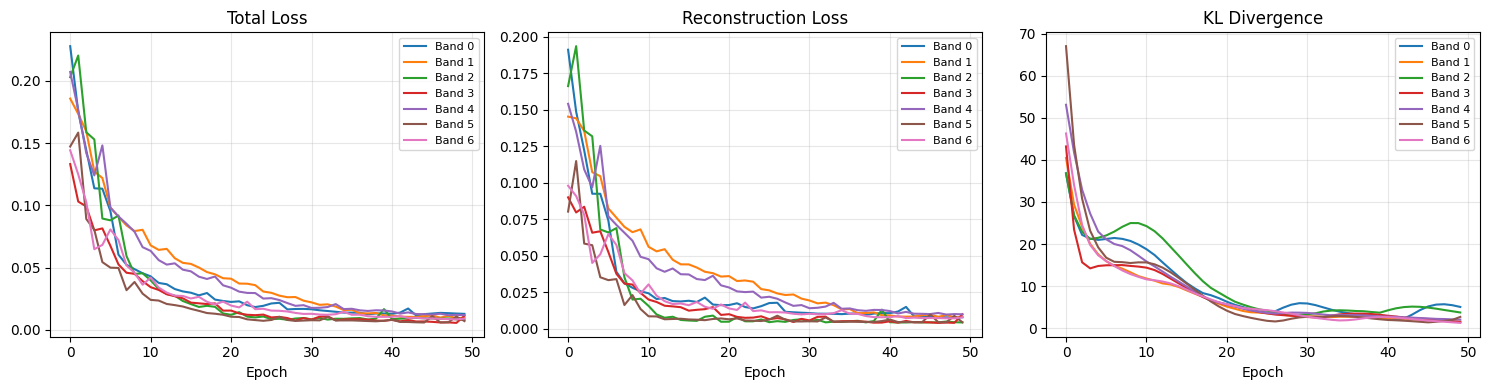

In [11]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for band_idx, history in histories.items():
    axes[0].plot(history["total"], label="Band {}".format(band_idx))
    axes[1].plot(history["recon"], label="Band {}".format(band_idx))
    axes[2].plot(history["kl"], label="Band {}".format(band_idx))

axes[0].set_title("Total Loss")
axes[1].set_title("Reconstruction Loss")
axes[2].set_title("KL Divergence")

for ax in axes:
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()